# 04. TTL Robustness Analysis

This notebook performs in-depth TTL perturbation strength sweeps (-15% to +15%), multi-seed reproducibility evaluations across seeds, granular attack-category sensitivity analysis under TTL shifts, and generates publication plots.


In [28]:
# ================================================================
# EXPERIMENT B — REPRODUCIBLE TTL PERTURBATION STRENGTH ANALYSIS
# FINAL VERSION
#
# Seeds: 42, 123, 2026
# Models: Random Forest + MLP
# TTL features: sttl, dttl
# Perturbations: -15%, -10%, -5%, -2%, 0%, +2%, +5%, +10%, +15%
#
# Results:
#   1. Per-seed results
#   2. Mean ± SD across the three seeds
#   3. CSV files for direct use in paper
# ================================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEEDS = [42, 123, 2026]

TTL_COLUMNS = ["sttl", "dttl"]

TTL_SCALES = [
    -0.15,
    -0.10,
    -0.05,
    -0.02,
     0.00,
     0.02,
     0.05,
     0.10,
     0.15
]

TARGET = "label"

DROP_COLS = [
    "label",
    "attack_cat"
]

EPOCHS = 10
BATCH_SIZE = 512
LEARNING_RATE = 1e-3

RF_ESTIMATORS = 200

print("=" * 90)
print("EXPERIMENT B — REPRODUCIBLE TTL PERTURBATION STRENGTH ANALYSIS")
print("=" * 90)

print("\nSeeds:", SEEDS)
print("TTL features:", TTL_COLUMNS)

print(
    "Perturbations:",
    [f"{int(x * 100):+d}%" for x in TTL_SCALES]
)


# ================================================================
# 2. REPRODUCIBILITY FUNCTION
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make PyTorch operations as deterministic as possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ================================================================
# 3. CHECK DATA
# ================================================================

required_variables = [
    "train_df",
    "test_df"
]

missing_variables = [
    x for x in required_variables
    if x not in globals()
]

if missing_variables:

    raise RuntimeError(
        f"Missing variables: {missing_variables}\n"
        "Make sure train_df and test_df are loaded."
    )


# ================================================================
# 4. PREPARE RAW FEATURES
# ================================================================

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_test = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)

print("\n" + "-" * 90)
print("DATA")
print("-" * 90)

print("Training shape:", X_train_raw.shape)
print("Testing shape :", X_test_raw.shape)

print("\nTraining labels:")
print(pd.Series(y_train).value_counts())

print("\nTesting labels:")
print(pd.Series(y_test).value_counts())


# ================================================================
# 5. FEATURE TYPES
# ================================================================

categorical_cols = (
    X_train_raw
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numeric_cols = (
    X_train_raw
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

print("\nNumeric features    :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)


# ================================================================
# 6. FIT ONE FIXED PREPROCESSOR
# ================================================================
#
# IMPORTANT:
# The preprocessor is fitted ONCE on the training data.
#
# Every seed and every perturbation uses this exact same
# preprocessing transformation.
#
# This prevents preprocessing differences from creating
# artificial differences between experiments.
# ================================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])

print("\nFitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape :",
    X_test_processed.shape
)


# ================================================================
# 7. MLP ARCHITECTURE
# ================================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ================================================================
# 8. TTL PERTURBATION
# ================================================================

def perturb_ttl(df, column, scale):

    out = df.copy()

    original = pd.to_numeric(
        out[column],
        errors="coerce"
    ).astype(float)

    # Multiplicative perturbation
    transformed = (
        original * (1.0 + scale)
    )

    # Valid IPv4 TTL range
    transformed = np.clip(
        transformed,
        1,
        255
    )

    # TTL is integer-valued
    out[column] = np.rint(
        transformed
    ).astype(int)

    return out


# ================================================================
# 9. EVALUATION FUNCTION
# ================================================================

def calculate_metrics(
    probability,
    y_true
):

    probability = np.asarray(
        probability
    )

    y_true = np.asarray(
        y_true
    )

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probability
    )

    auprc = average_precision_score(
        y_true,
        probability
    )

    attack_mask = (
        y_true == 1
    )

    if attack_mask.sum() > 0:

        evasion_rate = np.mean(
            prediction[attack_mask] == 0
        )

    else:

        evasion_rate = np.nan

    return (
        tpr,
        evasion_rate,
        auroc,
        auprc
    )


# ================================================================
# 10. TRAIN + EVALUATE ONE SEED
# ================================================================

all_results = []


for seed in SEEDS:

    print("\n\n")
    print("=" * 90)
    print(f"RUNNING SEED {seed}")
    print("=" * 90)

    # ------------------------------------------------------------
    # Set seed
    # ------------------------------------------------------------

    set_seed(seed)

    print(f"\nRandom seed: {seed}")


    # ============================================================
    # RANDOM FOREST
    # ============================================================

    print("\nTraining Random Forest...")

    rf = RandomForestClassifier(
        n_estimators=RF_ESTIMATORS,
        random_state=seed,
        n_jobs=-1
    )

    rf.fit(
        X_train_processed,
        y_train
    )


    # ============================================================
    # MLP
    # ============================================================

    print("Training MLP...")

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model = MLP(
        X_train_processed.shape[1]
    ).to(device)


    X_train_tensor = torch.tensor(
        X_train_processed,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.astype(np.float32),
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_processed,
        dtype=torch.float32
    )


    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )


    # ------------------------------------------------------------
    # IMPORTANT:
    # DataLoader gets a seeded generator.
    # This makes batch shuffling reproducible.
    # ------------------------------------------------------------

    loader_generator = torch.Generator()

    loader_generator.manual_seed(seed)


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )


    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # ------------------------------------------------------------
    # MLP training
    # ------------------------------------------------------------

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = model(
                batch_X
            )

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(batch_X)
            )


        avg_loss = (
            total_loss
            / len(train_dataset)
        )

        print(
            f"Seed {seed} | "
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Loss {avg_loss:.6f}"
        )


    # ============================================================
    # HELPER — MLP PREDICTION
    # ============================================================

    def mlp_predict(
        X_processed
    ):

        model.eval()

        X_tensor = torch.tensor(
            X_processed,
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():

            logits = model(
                X_tensor
            )

            probability = (
                torch.sigmoid(logits)
                .cpu()
                .numpy()
            )

        return probability


    # ============================================================
    # CLEAN BASELINE
    # ============================================================

    print("\nCalculating clean baseline...")


    # RF clean
    rf_clean_probability = rf.predict_proba(
        X_test_processed
    )[:, 1]


    (
        rf_clean_tpr,
        rf_clean_evasion,
        rf_clean_auroc,
        rf_clean_auprc
    ) = calculate_metrics(
        rf_clean_probability,
        y_test
    )


    # MLP clean
    mlp_clean_probability = mlp_predict(
        X_test_processed
    )


    (
        mlp_clean_tpr,
        mlp_clean_evasion,
        mlp_clean_auroc,
        mlp_clean_auprc
    ) = calculate_metrics(
        mlp_clean_probability,
        y_test
    )


    print("\nCLEAN BASELINE")
    print("-" * 60)

    print(
        f"RF  | "
        f"TPR={rf_clean_tpr:.6f} | "
        f"AUROC={rf_clean_auroc:.6f} | "
        f"AUPRC={rf_clean_auprc:.6f}"
    )

    print(
        f"MLP | "
        f"TPR={mlp_clean_tpr:.6f} | "
        f"AUROC={mlp_clean_auroc:.6f} | "
        f"AUPRC={mlp_clean_auprc:.6f}"
    )


    # ============================================================
    # TTL PERTURBATIONS
    # ============================================================

    for ttl_column in TTL_COLUMNS:

        print("\n" + "-" * 90)
        print(
            f"TTL FEATURE: {ttl_column}"
        )
        print("-" * 90)


        for scale in TTL_SCALES:

            scale_percent = (
                scale * 100
            )


            # ====================================================
            # CRITICAL:
            # At 0%, DO NOT transform the data.
            #
            # This guarantees that 0% is exactly the same
            # clean test condition.
            # ====================================================

            if scale == 0.0:

                X_processed = (
                    X_test_processed.copy()
                )

            else:

                transformed_df = perturb_ttl(
                    test_df,
                    ttl_column,
                    scale
                )

                X_transformed_raw = (
                    transformed_df[feature_cols]
                    .copy()
                )

                X_processed = (
                    preprocessor.transform(
                        X_transformed_raw
                    )
                )

                X_processed = np.asarray(
                    X_processed,
                    dtype=np.float32
                )


            # ====================================================
            # RF
            # ====================================================

            rf_probability = rf.predict_proba(
                X_processed
            )[:, 1]


            (
                rf_tpr,
                rf_evasion,
                rf_auroc,
                rf_auprc
            ) = calculate_metrics(
                rf_probability,
                y_test
            )


            # ====================================================
            # MLP
            # ====================================================

            mlp_probability = mlp_predict(
                X_processed
            )


            (
                mlp_tpr,
                mlp_evasion,
                mlp_auroc,
                mlp_auprc
            ) = calculate_metrics(
                mlp_probability,
                y_test
            )


            # ====================================================
            # TPR DEGRADATION
            #
            # POSITIVE = PERFORMANCE LOSS
            #
            # clean - perturbed
            # ====================================================

            rf_tpr_degradation = (
                rf_clean_tpr
                - rf_tpr
            )

            mlp_tpr_degradation = (
                mlp_clean_tpr
                - mlp_tpr
            )


            # ====================================================
            # STORE
            # ====================================================

            all_results.append({

                "Seed": seed,

                "TTL Feature":
                    ttl_column,

                "Scale":
                    scale,

                "Scale (%)":
                    scale_percent,

                "RF Clean TPR":
                    rf_clean_tpr,

                "RF TPR":
                    rf_tpr,

                "RF TPR Degradation":
                    rf_tpr_degradation,

                "RF Evasion Rate":
                    rf_evasion,

                "RF AUROC":
                    rf_auroc,

                "RF AUPRC":
                    rf_auprc,

                "MLP Clean TPR":
                    mlp_clean_tpr,

                "MLP TPR":
                    mlp_tpr,

                "MLP TPR Degradation":
                    mlp_tpr_degradation,

                "MLP Evasion Rate":
                    mlp_evasion,

                "MLP AUROC":
                    mlp_auroc,

                "MLP AUPRC":
                    mlp_auprc
            })


            print(
                f"{ttl_column:5s} "
                f"{scale_percent:+6.1f}% | "
                f"RF TPR={rf_tpr:.6f} | "
                f"MLP TPR={mlp_tpr:.6f}"
            )


# ================================================================
# 11. CREATE PER-SEED DATAFRAME
# ================================================================

per_seed_results = pd.DataFrame(
    all_results
)


print("\n\n")
print("=" * 110)
print("PER-SEED TTL PERTURBATION RESULTS")
print("=" * 110)


display(
    per_seed_results.round(6)
)


# ================================================================
# 12. SAVE PER-SEED RESULTS
# ================================================================

per_seed_results.to_csv(
    "TTL_results_per_seed.csv",
    index=False
)


# ================================================================
# 13. CALCULATE MEAN ± SD
# ================================================================

group_columns = [
    "TTL Feature",
    "Scale",
    "Scale (%)"
]


metric_columns = [

    "RF TPR",
    "RF TPR Degradation",
    "RF Evasion Rate",
    "RF AUROC",
    "RF AUPRC",

    "MLP TPR",
    "MLP TPR Degradation",
    "MLP Evasion Rate",
    "MLP AUROC",
    "MLP AUPRC"
]


mean_results = (
    per_seed_results
    .groupby(group_columns)[metric_columns]
    .mean()
    .reset_index()
)


std_results = (
    per_seed_results
    .groupby(group_columns)[metric_columns]
    .std(ddof=1)
    .reset_index()
)


# ================================================================
# 14. CREATE MEAN ± SD TABLE
# ================================================================

summary_results = mean_results[
    group_columns
].copy()


for metric in metric_columns:

    summary_results[
        metric + " Mean"
    ] = mean_results[metric]

    summary_results[
        metric + " SD"
    ] = std_results[metric]


# ================================================================
# 15. PAPER-FRIENDLY TABLE
# ================================================================

paper_table = summary_results[
    [
        "TTL Feature",
        "Scale (%)",

        "RF TPR Mean",
        "RF TPR SD",

        "RF TPR Degradation Mean",
        "RF TPR Degradation SD",

        "RF AUROC Mean",
        "RF AUROC SD",

        "RF AUPRC Mean",
        "RF AUPRC SD",

        "MLP TPR Mean",
        "MLP TPR SD",

        "MLP TPR Degradation Mean",
        "MLP TPR Degradation SD",

        "MLP AUROC Mean",
        "MLP AUROC SD",

        "MLP AUPRC Mean",
        "MLP AUPRC SD"
    ]
].copy()


# ================================================================
# 16. CREATE "MEAN ± SD" STRINGS
# ================================================================

final_table = pd.DataFrame({

    "TTL Feature":
        paper_table["TTL Feature"],

    "Scale (%)":
        paper_table["Scale (%)"],

    "RF TPR":
        paper_table.apply(
            lambda r:
                f"{r['RF TPR Mean']:.4f} ± "
                f"{r['RF TPR SD']:.4f}",
            axis=1
        ),

    "RF TPR Degradation":
        paper_table.apply(
            lambda r:
                f"{r['RF TPR Degradation Mean']:.4f} ± "
                f"{r['RF TPR Degradation SD']:.4f}",
            axis=1
        ),

    "RF AUROC":
        paper_table.apply(
            lambda r:
                f"{r['RF AUROC Mean']:.4f} ± "
                f"{r['RF AUROC SD']:.4f}",
            axis=1
        ),

    "RF AUPRC":
        paper_table.apply(
            lambda r:
                f"{r['RF AUPRC Mean']:.4f} ± "
                f"{r['RF AUPRC SD']:.4f}",
            axis=1
        ),

    "MLP TPR":
        paper_table.apply(
            lambda r:
                f"{r['MLP TPR Mean']:.4f} ± "
                f"{r['MLP TPR SD']:.4f}",
            axis=1
        ),

    "MLP TPR Degradation":
        paper_table.apply(
            lambda r:
                f"{r['MLP TPR Degradation Mean']:.4f} ± "
                f"{r['MLP TPR Degradation SD']:.4f}",
            axis=1
        ),

    "MLP AUROC":
        paper_table.apply(
            lambda r:
                f"{r['MLP AUROC Mean']:.4f} ± "
                f"{r['MLP AUROC SD']:.4f}",
            axis=1
        ),

    "MLP AUPRC":
        paper_table.apply(
            lambda r:
                f"{r['MLP AUPRC Mean']:.4f} ± "
                f"{r['MLP AUPRC SD']:.4f}",
            axis=1
        )
})


# ================================================================
# 17. DISPLAY FINAL PAPER TABLE
# ================================================================

print("\n\n")
print("=" * 120)
print("FINAL TABLE — MEAN ± SD ACROSS SEEDS 42, 123, 2026")
print("=" * 120)

display(
    final_table
)


# ================================================================
# 18. SAVE FINAL RESULTS
# ================================================================

summary_results.to_csv(
    "TTL_results_mean_sd.csv",
    index=False
)

final_table.to_csv(
    "Table_6_TTL_mean_SD.csv",
    index=False
)


# ================================================================
# 19. FINAL CHECK — 0% MUST MATCH CLEAN
# ================================================================

print("\n")
print("=" * 90)
print("ZERO-PERCENT CLEAN BASELINE CHECK")
print("=" * 90)


zero_percent = (
    per_seed_results[
        per_seed_results["Scale"] == 0.0
    ]
    .copy()
)


for seed in SEEDS:

    seed_data = zero_percent[
        zero_percent["Seed"] == seed
    ]


    print(f"\nSeed {seed}")

    for ttl_column in TTL_COLUMNS:

        row = seed_data[
            seed_data["TTL Feature"]
            == ttl_column
        ].iloc[0]


        rf_difference = (
            row["RF TPR"]
            - row["RF Clean TPR"]
        )

        mlp_difference = (
            row["MLP TPR"]
            - row["MLP Clean TPR"]
        )


        print(
            f"{ttl_column}: "
            f"RF difference={rf_difference:.12f}, "
            f"MLP difference={mlp_difference:.12f}"
        )


# ================================================================
# 20. FINAL FILES
# ================================================================

print("\n")
print("=" * 90)
print("EXPERIMENT B COMPLETE")
print("=" * 90)

print("\nFiles generated:")

print(
    "1. TTL_results_per_seed.csv"
)

print(
    "2. TTL_results_mean_sd.csv"
)

print(
    "3. Table_6_TTL_mean_SD.csv"
)

print(
    "\nOfficial seeds:",
    SEEDS
)

print(
    "\nTPR degradation definition:"
)

print(
    "Clean TPR - Perturbed TPR"
)

print(
    "\nPaper reporting:"
)

print(
    "Mean ± SD across seeds 42, 123, and 2026"
)

EXPERIMENT B — REPRODUCIBLE TTL PERTURBATION STRENGTH ANALYSIS

Seeds: [42, 123, 2026]
TTL features: ['sttl', 'dttl']
Perturbations: ['-15%', '-10%', '-5%', '-2%', '+0%', '+2%', '+5%', '+10%', '+15%']

------------------------------------------------------------------------------------------
DATA
------------------------------------------------------------------------------------------
Training shape: (175341, 43)
Testing shape : (82332, 43)

Training labels:
1    119341
0     56000
Name: count, dtype: int64

Testing labels:
1    45332
0    37000
Name: count, dtype: int64

Numeric features    : 40
Categorical features: 3

Categorical columns:
['proto', 'service', 'state']

Fitting preprocessing pipeline...
Processed training shape: (175341, 195)
Processed testing shape : (82332, 195)



RUNNING SEED 42

Random seed: 42

Training Random Forest...
Training MLP...
Seed 42 | Epoch 01/10 | Loss 0.160476
Seed 42 | Epoch 02/10 | Loss 0.099631
Seed 42 | Epoch 03/10 | Loss 0.091877
Seed 42 | Ep

,Seed,TTL Feature,Scale,Scale (%),RF Clean TPR,RF TPR,RF TPR Degradation,RF Evasion Rate,RF AUROC,RF AUPRC,MLP Clean TPR,MLP TPR,MLP TPR Degradation,MLP Evasion Rate,MLP AUROC,MLP AUPRC
0,42,sttl,-0.15,-15.0,0.716712,0.695557,0.021155,0.304443,0.804718,0.816645,0.437483,0.427645,0.009839,0.572355,0.661275,0.744603
1,42,sttl,-0.10,-10.0,0.716712,0.695557,0.021155,0.304443,0.804718,0.816645,0.437483,0.430954,0.006530,0.569046,0.665077,0.748053
2,42,sttl,-0.05,-5.0,0.716712,0.695557,0.021155,0.304443,0.804718,0.816645,0.437483,0.433888,0.003596,0.566112,0.668537,0.750974
3,42,sttl,-0.02,-2.0,0.716712,0.695557,0.021155,0.304443,0.804719,0.816648,0.437483,0.436226,0.001257,0.563774,0.670669,0.752734
4,42,sttl,0.00,0.0,0.716712,0.716712,0.000000,0.283288,0.805111,0.819160,0.437483,0.437483,0.000000,0.562517,0.671884,0.753734
5,42,sttl,0.02,2.0,0.716712,0.716800,-0.000088,0.283200,0.805107,0.819167,0.437483,0.437770,-0.000287,0.562230,0.671992,0.753884
6,42,sttl,0.05,5.0,0.716712,0.716800,-0.000088,0.283200,0.805075,0.819151,0.437483,0.437726,-0.000243,0.562274,0.671852,0.753844
7,42,sttl,0.10,10.0,0.716712,0.716800,-0.000088,0.283200,0.805076,0.819151,0.437483,0.437858,-0.000375,0.562142,0.671730,0.753803
8,42,sttl,0.15,15.0,0.716712,0.716800,-0.000088,0.283200,0.805076,0.819151,0.437483,0.437881,-0.000397,0.562119,0.671407,0.753680
9,42,dttl,-0.15,-15.0,0.716712,0.716712,0.000000,0.283288,0.805112,0.819161,0.437483,0.396210,0.041273,0.603790,0.657684,0.740830





FINAL TABLE — MEAN ± SD ACROSS SEEDS 42, 123, 2026


,TTL Feature,Scale (%),RF TPR,RF TPR Degradation,RF AUROC,RF AUPRC,MLP TPR,MLP TPR Degradation,MLP AUROC,MLP AUPRC
0,dttl,-15.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.3853 ± 0.0158,0.0382 ± 0.0027,0.6468 ± 0.0121,0.7356 ± 0.0045
1,dttl,-10.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.3966 ± 0.0165,0.0269 ± 0.0018,0.6517 ± 0.0123,0.7400 ± 0.0044
2,dttl,-5.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.4090 ± 0.0173,0.0146 ± 0.0007,0.6562 ± 0.0125,0.7443 ± 0.0042
3,dttl,-2.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.4176 ± 0.0176,0.0059 ± 0.0007,0.6599 ± 0.0125,0.7476 ± 0.0041
4,dttl,0.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.4235 ± 0.0175,0.0000 ± 0.0000,0.6615 ± 0.0127,0.7494 ± 0.0039
5,dttl,2.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4271 ± 0.0175,-0.0035 ± 0.0000,0.6628 ± 0.0129,0.7507 ± 0.0039
6,dttl,5.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4271 ± 0.0175,-0.0035 ± 0.0000,0.6628 ± 0.0128,0.7507 ± 0.0039
7,dttl,10.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4271 ± 0.0175,-0.0035 ± 0.0000,0.6619 ± 0.0131,0.7504 ± 0.0040
8,dttl,15.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4271 ± 0.0175,-0.0035 ± 0.0000,0.6615 ± 0.0132,0.7503 ± 0.0040
9,sttl,-15.0,0.6655 ± 0.0261,0.0175 ± 0.0109,0.7983 ± 0.0057,0.8094 ± 0.0066,0.4145 ± 0.0178,0.0091 ± 0.0013,0.6523 ± 0.0132,0.7412 ± 0.0041




ZERO-PERCENT CLEAN BASELINE CHECK

Seed 42
sttl: RF difference=0.000000000000, MLP difference=0.000000000000
dttl: RF difference=0.000000000000, MLP difference=0.000000000000

Seed 123
sttl: RF difference=0.000000000000, MLP difference=0.000000000000
dttl: RF difference=0.000000000000, MLP difference=0.000000000000

Seed 2026
sttl: RF difference=0.000000000000, MLP difference=0.000000000000
dttl: RF difference=0.000000000000, MLP difference=0.000000000000


EXPERIMENT B COMPLETE

Files generated:
1. TTL_results_per_seed.csv
2. TTL_results_mean_sd.csv
3. Table_6_TTL_mean_SD.csv

Official seeds: [42, 123, 2026]

TPR degradation definition:
Clean TPR - Perturbed TPR

Paper reporting:
Mean ± SD across seeds 42, 123, and 2026


In [ ]:
# ================================================================
# EXPERIMENT C — MULTI-SEED TTL ROBUSTNESS / REPRODUCIBILITY
# ================================================================

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("EXPERIMENT C — MULTI-SEED TTL ROBUSTNESS")
print("=" * 80)

# ------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------

SEEDS = [42, 123, 2026, 7, 99]

TTL_FEATURES = ["sttl", "dttl"]

PERTURBATION_LEVELS = [
    -15, -10, -5, -2, 0, 2, 5, 10, 15
]

print("Seeds:", SEEDS)
print("TTL features:", TTL_FEATURES)
print("Perturbations (%):", PERTURBATION_LEVELS)


# ------------------------------------------------
# 2. REPRODUCIBILITY FUNCTION
# ------------------------------------------------

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------------------------------
# 3. CHECK REQUIRED VARIABLES
# ------------------------------------------------

required_vars = [
    "train_df",
    "test_df",
    "preprocessor"
]

missing = [
    v for v in required_vars
    if v not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Run the data-loading and preprocessing cells first."
    )

print("\nRequired variables found.")


# ------------------------------------------------
# 4. TARGET / FEATURE SETUP
# ------------------------------------------------

TARGET = "label"

if TARGET not in train_df.columns:
    raise ValueError("Column 'label' not found in training data.")

if TARGET not in test_df.columns:
    raise ValueError("Column 'label' not found in test data.")

y_train_c = train_df[TARGET].astype(int).to_numpy()
y_test_c = test_df[TARGET].astype(int).to_numpy()

print("Training samples:", len(y_train_c))
print("Test samples:", len(y_test_c))


# ------------------------------------------------
# 5. RAW FEATURE DATA
# ------------------------------------------------

X_train_raw_c = train_df.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
).copy()

X_test_raw_c = test_df.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
).copy()

print("Raw training shape:", X_train_raw_c.shape)
print("Raw test shape:", X_test_raw_c.shape)


# ------------------------------------------------
# 6. APPLY THE ALREADY-FITTED PREPROCESSOR
# ------------------------------------------------

print("\nTransforming training data...")

X_train_c = preprocessor.transform(X_train_raw_c)

print("Processed training shape:", X_train_c.shape)


print("Transforming clean test data...")

X_test_clean_c = preprocessor.transform(X_test_raw_c)

print("Processed clean test shape:", X_test_clean_c.shape)


# ------------------------------------------------
# 7. MLP DEFINITION
# ------------------------------------------------

class MLP_C(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ------------------------------------------------
# 8. MLP TRAINING FUNCTION
# ------------------------------------------------

def train_mlp_c(X_train, y_train, seed, epochs=10):

    set_seed(seed)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"      MLP device: {device}")

    model_c = MLP_C(
        input_dim=X_train.shape[1]
    ).to(device)

    X_tensor = torch.tensor(
        X_train,
        dtype=torch.float32,
        device=device
    )

    y_tensor = torch.tensor(
        y_train,
        dtype=torch.float32,
        device=device
    )

    dataset = torch.utils.data.TensorDataset(
        X_tensor,
        y_tensor
    )

    # Fixed generator gives reproducible shuffling
    generator = torch.Generator()

    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=2048,
        shuffle=True,
        generator=generator
    )

    # Handle class imbalance
    positives = y_train.sum()
    negatives = len(y_train) - positives

    pos_weight = torch.tensor(
        [negatives / positives],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.Adam(
        model_c.parameters(),
        lr=0.001
    )

    model_c.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model_c(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"      Epoch {epoch + 1:02d}/{epochs} "
            f"- Loss: {total_loss / len(loader):.6f}"
        )

    return model_c


# ------------------------------------------------
# 9. MLP EVALUATION FUNCTION
# ------------------------------------------------

def evaluate_mlp_c(model_c, X_processed, y_true):

    device = next(
        model_c.parameters()
    ).device

    model_c.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X_processed,
            dtype=torch.float32,
            device=device
        )

        logits = model_c(
            X_tensor
        )

        probability = (
            torch.sigmoid(logits)
            .detach()
            .cpu()
            .numpy()
        )

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probability
    )

    auprc = average_precision_score(
        y_true,
        probability
    )

    attack_mask = (
        np.asarray(y_true) == 1
    )

    evasion_rate = np.mean(
        prediction[attack_mask] == 0
    )

    return {
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Evasion_Rate": evasion_rate
    }


# ------------------------------------------------
# 10. RF EVALUATION FUNCTION
# ------------------------------------------------

def evaluate_rf_c(model_rf, X_processed, y_true):

    probability = model_rf.predict_proba(
        X_processed
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probability
    )

    auprc = average_precision_score(
        y_true,
        probability
    )

    attack_mask = (
        np.asarray(y_true) == 1
    )

    evasion_rate = np.mean(
        prediction[attack_mask] == 0
    )

    return {
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Evasion_Rate": evasion_rate
    }


# ------------------------------------------------
# 11. TTL TRANSFORMATION FUNCTION
# ------------------------------------------------

def perturb_ttl_c(df, feature, percent):

    df_new = df.copy()

    if feature not in df_new.columns:
        raise ValueError(
            f"{feature} not found in dataframe."
        )

    # Percentage perturbation
    transformed = (
        df_new[feature].astype(float)
        * (1.0 + percent / 100.0)
    )

    # TTL is an integer-valued bounded network feature.
    # Keep transformed values technically valid.
    transformed = np.round(transformed)

    transformed = np.clip(
        transformed,
        1,
        255
    )

    df_new[feature] = transformed.astype(
        df_new[feature].dtype
    )

    return df_new


# ------------------------------------------------
# 12. MULTI-SEED EXPERIMENT
# ------------------------------------------------

all_results_c = []

for seed in SEEDS:

    print("\n")
    print("=" * 80)
    print(f"SEED {seed}")
    print("=" * 80)

    set_seed(seed)

    # ============================================================
    # TRAIN RANDOM FOREST
    # ============================================================

    print("\nTraining Random Forest...")

    rf_c = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt"
    )

    rf_c.fit(
        X_train_c,
        y_train_c
    )

    # ============================================================
    # TRAIN MLP
    # ============================================================

    print("\nTraining MLP...")

    mlp_c = train_mlp_c(
        X_train_c,
        y_train_c,
        seed=seed,
        epochs=10
    )

    # ============================================================
    # CLEAN BASELINE
    # ============================================================

    rf_clean = evaluate_rf_c(
        rf_c,
        X_test_clean_c,
        y_test_c
    )

    mlp_clean = evaluate_mlp_c(
        mlp_c,
        X_test_clean_c,
        y_test_c
    )

    print("\nCLEAN BASELINE")

    print(
        f"RF  TPR: {rf_clean['TPR']:.6f}"
    )

    print(
        f"MLP TPR: {mlp_clean['TPR']:.6f}"
    )

    # ============================================================
    # TTL PERTURBATIONS
    # ============================================================

    for feature in TTL_FEATURES:

        print("\n" + "-" * 70)
        print(
            f"Testing {feature} perturbations"
        )
        print("-" * 70)

        for percent in PERTURBATION_LEVELS:

            # Clean row
            if percent == 0:

                X_transformed = X_test_clean_c

            else:

                transformed_raw = perturb_ttl_c(
                    X_test_raw_c,
                    feature,
                    percent
                )

                X_transformed = preprocessor.transform(
                    transformed_raw
                )

            # -----------------------------
            # RF
            # -----------------------------

            rf_result = evaluate_rf_c(
                rf_c,
                X_transformed,
                y_test_c
            )

            # -----------------------------
            # MLP
            # -----------------------------

            mlp_result = evaluate_mlp_c(
                mlp_c,
                X_transformed,
                y_test_c
            )

            # -----------------------------
            # Drops relative to SAME seed
            # -----------------------------

            rf_tpr_drop = (
                rf_result["TPR"]
                - rf_clean["TPR"]
            )

            mlp_tpr_drop = (
                mlp_result["TPR"]
                - mlp_clean["TPR"]
            )

            all_results_c.append({

                "Seed": seed,

                "TTL Feature": feature,

                "Perturbation (%)": percent,

                "RF TPR": rf_result["TPR"],

                "RF TPR Drop": rf_tpr_drop,

                "RF Evasion Rate":
                    rf_result["Evasion_Rate"],

                "RF AUROC":
                    rf_result["AUROC"],

                "RF AUPRC":
                    rf_result["AUPRC"],

                "MLP TPR": mlp_result["TPR"],

                "MLP TPR Drop":
                    mlp_tpr_drop,

                "MLP Evasion Rate":
                    mlp_result["Evasion_Rate"],

                "MLP AUROC":
                    mlp_result["AUROC"],

                "MLP AUPRC":
                    mlp_result["AUPRC"]
            })

            print(
                f"{feature:5s} "
                f"{percent:+4d}% | "
                f"RF ΔTPR={rf_tpr_drop:+.6f} | "
                f"MLP ΔTPR={mlp_tpr_drop:+.6f}"
            )


# ------------------------------------------------
# 13. RESULTS DATAFRAME
# ------------------------------------------------

seed_results_df = pd.DataFrame(
    all_results_c
)

print("\n")
print("=" * 100)
print("MULTI-SEED TTL RESULTS")
print("=" * 100)

print(
    seed_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------
# 14. AGGREGATE MEAN ± SD
# ------------------------------------------------

group_cols = [
    "TTL Feature",
    "Perturbation (%)"
]

metric_cols = [
    "RF TPR",
    "RF TPR Drop",
    "RF Evasion Rate",
    "RF AUROC",
    "RF AUPRC",
    "MLP TPR",
    "MLP TPR Drop",
    "MLP Evasion Rate",
    "MLP AUROC",
    "MLP AUPRC"
]

mean_df = (
    seed_results_df
    .groupby(group_cols)[metric_cols]
    .mean()
    .reset_index()
)

std_df = (
    seed_results_df
    .groupby(group_cols)[metric_cols]
    .std(ddof=1)
    .reset_index()
)

# Rename metric columns
mean_df = mean_df.rename(
    columns={
        col: col + " Mean"
        for col in metric_cols
    }
)

std_df = std_df.rename(
    columns={
        col: col + " SD"
        for col in metric_cols
    }
)

summary_c = mean_df.merge(
    std_df,
    on=group_cols
)

print("\n")
print("=" * 100)
print("MULTI-SEED SUMMARY — MEAN ± SD")
print("=" * 100)

print(
    summary_c.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------
# 15. SAVE RESULTS
# ------------------------------------------------

seed_results_df.to_csv(
    "ttl_multiseed_results.csv",
    index=False
)

summary_c.to_csv(
    "ttl_multiseed_mean_sd.csv",
    index=False
)

print("\nResults saved:")
print("  ttl_multiseed_results.csv")
print("  ttl_multiseed_mean_sd.csv")

print("\n")
print("=" * 80)
print("EXPERIMENT C COMPLETE")
print("=" * 80)

EXPERIMENT C — MULTI-SEED TTL ROBUSTNESS
Seeds: [42, 123, 2026, 7, 99]
TTL features: ['sttl', 'dttl']
Perturbations (%): [-15, -10, -5, -2, 0, 2, 5, 10, 15]

Required variables found.
Training samples: 175341
Test samples: 82332
Raw training shape: (175341, 43)
Raw test shape: (82332, 43)

Transforming training data...
Processed training shape: (175341, 195)
Transforming clean test data...
Processed clean test shape: (82332, 195)


SEED 42

Training Random Forest...

Training MLP...
      MLP device: cuda
      Epoch 01/10 - Loss: 0.203297
      Epoch 02/10 - Loss: 0.075856
      Epoch 03/10 - Loss: 0.071872
      Epoch 04/10 - Loss: 0.069723
      Epoch 05/10 - Loss: 0.067452
      Epoch 06/10 - Loss: 0.065762
      Epoch 07/10 - Loss: 0.064025
      Epoch 08/10 - Loss: 0.061985
      Epoch 09/10 - Loss: 0.060031
      Epoch 10/10 - Loss: 0.056803

CLEAN BASELINE
RF  TPR: 0.670387
MLP TPR: 0.644534

----------------------------------------------------------------------
Testing sttl pe

In [ ]:
# ================================================================
# EXPERIMENT D
# ATTACK-CATEGORY × TTL PERTURBATION × MULTI-SEED ANALYSIS
# ================================================================

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score


print("=" * 90)
print("EXPERIMENT D — ATTACK CATEGORY × TTL PERTURBATION")
print("=" * 90)


# ================================================================
# 1. SETTINGS
# ================================================================

SEEDS = [42, 123, 2026, 7, 99]

TTL_FEATURES = ["sttl", "dttl"]

PERTURBATIONS = [
    -15, -10, -5, -2, 0, 2, 5, 10, 15
]

TARGET = "label"
CATEGORY = "attack_cat"


# ================================================================
# 2. CHECK DATA
# ================================================================

required = [
    "train_df",
    "test_df",
    "preprocessor"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run the data-loading/preprocessing cells first."
    )


if CATEGORY not in test_df.columns:
    raise ValueError(
        "attack_cat is not present in test_df."
    )


print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(
    "\nAttack categories:"
)

print(
    test_df[CATEGORY]
    .value_counts()
    .to_string()
)


# ================================================================
# 3. REPRODUCIBILITY
# ================================================================

def set_seed_d(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ================================================================
# 4. RAW FEATURES
# ================================================================

X_train_raw_d = train_df.drop(
    columns=[TARGET, CATEGORY],
    errors="ignore"
).copy()

X_test_raw_d = test_df.drop(
    columns=[TARGET, CATEGORY],
    errors="ignore"
).copy()

y_train_d = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_test_d = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)

attack_categories_d = (
    test_df[CATEGORY]
    .astype(str)
    .to_numpy()
)


# ================================================================
# 5. PREPROCESS
# ================================================================

print("\nTransforming training data...")

X_train_d = preprocessor.transform(
    X_train_raw_d
)

print(
    "Processed training:",
    X_train_d.shape
)


print("Transforming test data...")

X_test_clean_d = preprocessor.transform(
    X_test_raw_d
)

print(
    "Processed test:",
    X_test_clean_d.shape
)


# ================================================================
# 6. MLP
# ================================================================

class MLP_D(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ================================================================
# 7. TRAIN MLP
# ================================================================

def train_mlp_d(X, y, seed, epochs=10):

    set_seed_d(seed)

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    model = MLP_D(
        X.shape[1]
    ).to(device)

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=device
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
        device=device
    )

    dataset = torch.utils.data.TensorDataset(
        X_tensor,
        y_tensor
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=2048,
        shuffle=True,
        generator=generator
    )

    positives = y.sum()
    negatives = len(y) - positives

    pos_weight = torch.tensor(
        [negatives / positives],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

    return model


# ================================================================
# 8. MLP PREDICTIONS
# ================================================================

def mlp_predict_d(model, X):

    device = next(
        model.parameters()
    ).device

    model.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=device
        )

        logits = model(
            X_tensor
        )

        probabilities = (
            torch.sigmoid(logits)
            .detach()
            .cpu()
            .numpy()
        )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return predictions


# ================================================================
# 9. TTL TRANSFORMATION
# ================================================================

def perturb_ttl_d(df, feature, percent):

    df_new = df.copy()

    values = (
        df_new[feature]
        .astype(float)
        .to_numpy()
    )

    transformed = (
        values *
        (1 + percent / 100.0)
    )

    # TTL values are kept integer-valued
    transformed = np.round(
        transformed
    )

    # Technically valid TTL range
    transformed = np.clip(
        transformed,
        1,
        255
    )

    df_new[feature] = transformed

    return df_new


# ================================================================
# 10. CATEGORY TPR FUNCTION
# ================================================================

def category_tpr_d(
    y_true,
    predictions,
    categories
):

    output = []

    unique_categories = sorted(
        np.unique(categories)
    )

    for category in unique_categories:

        # Only ATTACK samples
        mask = (
            (categories == category)
            &
            (y_true == 1)
        )

        n = mask.sum()

        if n == 0:
            continue

        tpr = np.mean(
            predictions[mask] == 1
        )

        output.append({

            "Attack Category": category,

            "Samples": int(n),

            "TPR": float(tpr)
        })

    return pd.DataFrame(output)


# ================================================================
# 11. RUN EXPERIMENT
# ================================================================

results_d = []

for seed in SEEDS:

    print("\n")
    print("=" * 90)
    print(f"SEED {seed}")
    print("=" * 90)

    set_seed_d(seed)


    # ------------------------------------------------------------
    # RANDOM FOREST
    # ------------------------------------------------------------

    print("Training Random Forest...")

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt"
    )

    rf.fit(
        X_train_d,
        y_train_d
    )


    # ------------------------------------------------------------
    # MLP
    # ------------------------------------------------------------

    print("Training MLP...")

    mlp = train_mlp_d(
        X_train_d,
        y_train_d,
        seed,
        epochs=10
    )


    # ------------------------------------------------------------
    # CLEAN PREDICTIONS
    # ------------------------------------------------------------

    rf_clean_pred = rf.predict(
        X_test_clean_d
    )

    mlp_clean_pred = mlp_predict_d(
        mlp,
        X_test_clean_d
    )


    # ------------------------------------------------------------
    # LOOP FEATURES
    # ------------------------------------------------------------

    for feature in TTL_FEATURES:

        print(
            f"\nTesting {feature}..."
        )

        for percent in PERTURBATIONS:

            # ----------------------------------------------------
            # CLEAN
            # ----------------------------------------------------

            if percent == 0:

                X_transformed = (
                    X_test_clean_d
                )

            # ----------------------------------------------------
            # PERTURBED
            # ----------------------------------------------------

            else:

                transformed_raw = (
                    perturb_ttl_d(
                        X_test_raw_d,
                        feature,
                        percent
                    )
                )

                X_transformed = (
                    preprocessor.transform(
                        transformed_raw
                    )
                )


            # ----------------------------------------------------
            # PREDICTIONS
            # ----------------------------------------------------

            rf_pred = rf.predict(
                X_transformed
            )

            mlp_pred = mlp_predict_d(
                mlp,
                X_transformed
            )


            # ----------------------------------------------------
            # CATEGORY RESULTS
            # ----------------------------------------------------

            rf_cat = category_tpr_d(
                y_test_d,
                rf_pred,
                attack_categories_d
            )

            mlp_cat = category_tpr_d(
                y_test_d,
                mlp_pred,
                attack_categories_d
            )


            # ----------------------------------------------------
            # MERGE RF + MLP
            # ----------------------------------------------------

            merged = rf_cat.merge(
                mlp_cat,
                on=[
                    "Attack Category",
                    "Samples"
                ],
                suffixes=(
                    "_RF",
                    "_MLP"
                )
            )


            for _, row in merged.iterrows():

                results_d.append({

                    "Seed": seed,

                    "TTL Feature": feature,

                    "Perturbation (%)": percent,

                    "Attack Category":
                        row["Attack Category"],

                    "Samples":
                        row["Samples"],

                    "RF TPR":
                        row["TPR_RF"],

                    "MLP TPR":
                        row["TPR_MLP"]
                })


            print(
                f"  {feature:5s} "
                f"{percent:+4d}% completed"
            )


# ================================================================
# 12. RAW RESULTS
# ================================================================

category_results_d = pd.DataFrame(
    results_d
)

print("\n")
print("=" * 100)
print("ATTACK CATEGORY RESULTS")
print("=" * 100)

print(
    category_results_d.head(30)
    .to_string(index=False)
)


# ================================================================
# 13. CALCULATE WITHIN-SEED CATEGORY TPR DROP
# ================================================================

clean_reference = (
    category_results_d[
        category_results_d["Perturbation (%)"] == 0
    ]
    [
        [
            "Seed",
            "TTL Feature",
            "Attack Category",
            "RF TPR",
            "MLP TPR"
        ]
    ]
    .rename(
        columns={
            "RF TPR":
                "RF Clean TPR",

            "MLP TPR":
                "MLP Clean TPR"
        }
    )
)

category_with_drop = (
    category_results_d
    .merge(
        clean_reference,
        on=[
            "Seed",
            "TTL Feature",
            "Attack Category"
        ],
        how="left"
    )
)

category_with_drop[
    "RF TPR Drop"
] = (
    category_with_drop["RF TPR"]
    -
    category_with_drop["RF Clean TPR"]
)

category_with_drop[
    "MLP TPR Drop"
] = (
    category_with_drop["MLP TPR"]
    -
    category_with_drop["MLP Clean TPR"]
)


# ================================================================
# 14. MULTI-SEED MEAN
# ================================================================

group_cols_d = [
    "TTL Feature",
    "Perturbation (%)",
    "Attack Category"
]

mean_category_d = (
    category_with_drop
    .groupby(group_cols_d)
    [
        [
            "Samples",
            "RF TPR",
            "RF TPR Drop",
            "MLP TPR",
            "MLP TPR Drop"
        ]
    ]
    .mean()
    .reset_index()
)


# ================================================================
# 15. MULTI-SEED SD
# ================================================================

sd_category_d = (
    category_with_drop
    .groupby(group_cols_d)
    [
        [
            "RF TPR",
            "RF TPR Drop",
            "MLP TPR",
            "MLP TPR Drop"
        ]
    ]
    .std(ddof=1)
    .reset_index()
)

sd_category_d = sd_category_d.rename(
    columns={
        "RF TPR":
            "RF TPR SD",

        "RF TPR Drop":
            "RF TPR Drop SD",

        "MLP TPR":
            "MLP TPR SD",

        "MLP TPR Drop":
            "MLP TPR Drop SD"
    }
)


# ================================================================
# 16. MERGE MEAN + SD
# ================================================================

category_summary_d = mean_category_d.merge(
    sd_category_d,
    on=group_cols_d
)


# ================================================================
# 17. 95% CONFIDENCE INTERVALS
# ================================================================

n_seeds = len(SEEDS)

t_critical = 2.776

for metric in [
    "RF TPR Drop",
    "MLP TPR Drop"
]:

    sd_col = metric + " SD"

    se = (
        category_summary_d[sd_col]
        / np.sqrt(n_seeds)
    )

    category_summary_d[
        metric + " CI Low"
    ] = (
        category_summary_d[metric]
        -
        t_critical * se
    )

    category_summary_d[
        metric + " CI High"
    ] = (
        category_summary_d[metric]
        +
        t_critical * se
    )


# ================================================================
# 18. SAVE EVERYTHING
# ================================================================

category_results_d.to_csv(
    "ttl_attack_category_seed_results.csv",
    index=False
)

category_with_drop.to_csv(
    "ttl_attack_category_seed_drops.csv",
    index=False
)

category_summary_d.to_csv(
    "ttl_attack_category_mean_sd_ci.csv",
    index=False
)


# ================================================================
# 19. PRINT MOST IMPORTANT RESULTS
# ================================================================

print("\n")
print("=" * 120)
print("CATEGORY-WISE MULTI-SEED SUMMARY")
print("=" * 120)

display(
    category_summary_d[
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category",
            "Samples",
            "RF TPR",
            "RF TPR Drop",
            "MLP TPR",
            "MLP TPR Drop"
        ]
    ]
    .sort_values(
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category"
        ]
    )
)


# ================================================================
# 20. PARTICULARLY IMPORTANT: EXPLOITS + DoS
# ================================================================

important_categories = [
    "Exploits",
    "DoS"
]

important_results_d = (
    category_summary_d[
        category_summary_d[
            "Attack Category"
        ].isin(important_categories)
    ]
    .sort_values(
        [
            "TTL Feature",
            "Attack Category",
            "Perturbation (%)"
        ]
    )
)

print("\n")
print("=" * 120)
print("EXPLOITS + DoS — KEY RESULTS")
print("=" * 120)

display(
    important_results_d[
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category",
            "Samples",

            "RF TPR",
            "RF TPR Drop",

            "MLP TPR",
            "MLP TPR Drop",

            "MLP TPR Drop CI Low",
            "MLP TPR Drop CI High"
        ]
    ]
)


# ================================================================
# 21. STRONGEST CATEGORY DEGRADATIONS
# ================================================================

negative_results = category_summary_d[
    category_summary_d["Perturbation (%)"] < 0
].copy()

strongest = (
    negative_results
    .sort_values(
        "MLP TPR Drop"
    )
    .head(15)
)

print("\n")
print("=" * 120)
print("STRONGEST MLP CATEGORY DEGRADATIONS")
print("=" * 120)

display(
    strongest[
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category",
            "Samples",
            "MLP TPR",
            "MLP TPR Drop",
            "MLP TPR Drop SD",
            "MLP TPR Drop CI Low",
            "MLP TPR Drop CI High"
        ]
    ]
)


# ================================================================
# 22. COMPLETE
# ================================================================

print("\n")
print("=" * 90)
print("EXPERIMENT D COMPLETE")
print("=" * 90)

print("\nSaved files:")

print(
    "1. ttl_attack_category_seed_results.csv"
)

print(
    "2. ttl_attack_category_seed_drops.csv"
)

print(
    "3. ttl_attack_category_mean_sd_ci.csv"
)

EXPERIMENT D — ATTACK CATEGORY × TTL PERTURBATION
Training shape: (175341, 45)
Test shape: (82332, 45)

Attack categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44

Transforming training data...
Processed training: (175341, 195)
Transforming test data...
Processed test: (82332, 195)


SEED 42
Training Random Forest...
Training MLP...

Testing sttl...
  sttl   -15% completed
  sttl   -10% completed
  sttl    -5% completed
  sttl    -2% completed
  sttl    +0% completed
  sttl    +2% completed
  sttl    +5% completed
  sttl   +10% completed
  sttl   +15% completed

Testing dttl...
  dttl   -15% completed
  dttl   -10% completed
  dttl    -5% completed
  dttl    -2% completed
  dttl    +0% completed
  dttl    +2% completed
  dttl    +5% completed
  dttl   +10% completed
  dttl   +15

,TTL Feature,Perturbation (%),Attack Category,Samples,RF TPR,RF TPR Drop,MLP TPR,MLP TPR Drop
0,dttl,-15,Analysis,677.0,0.780502,0.000000,0.912260,-0.032496
1,dttl,-15,Backdoor,583.0,0.907719,0.000000,0.932419,-0.018868
2,dttl,-15,DoS,4089.0,0.342822,0.000000,0.707117,-0.032331
3,dttl,-15,Exploits,11132.0,0.466798,0.000000,0.550826,-0.082681
4,dttl,-15,Fuzzers,6062.0,0.595711,0.000000,0.348928,-0.115968
...,...,...,...,...,...,...,...,...
157,sttl,15,Fuzzers,6062.0,0.595282,-0.000429,0.466711,0.001815
158,sttl,15,Generic,18871.0,0.983986,-0.000191,0.760712,0.002978
159,sttl,15,Reconnaissance,3496.0,0.359439,-0.000915,0.498799,0.000572
160,sttl,15,Shellcode,378.0,0.394180,0.000000,0.474603,0.001058




EXPLOITS + DoS — KEY RESULTS


,TTL Feature,Perturbation (%),Attack Category,Samples,RF TPR,RF TPR Drop,MLP TPR,MLP TPR Drop,MLP TPR Drop CI Low,MLP TPR Drop CI High
2,dttl,-15,DoS,4089.0,0.342822,0.000000,0.707117,-0.032331,-0.041851,-0.022811
11,dttl,-10,DoS,4089.0,0.342822,0.000000,0.717339,-0.022108,-0.027705,-0.016511
20,dttl,-5,DoS,4089.0,0.342822,0.000000,0.728051,-0.011396,-0.014376,-0.008417
29,dttl,-2,DoS,4089.0,0.342822,0.000000,0.735485,-0.003962,-0.005501,-0.002423
38,dttl,0,DoS,4089.0,0.342822,0.000000,0.739447,0.000000,0.000000,0.000000
47,dttl,2,DoS,4089.0,0.342431,-0.000391,0.741795,0.002348,0.001473,0.003222
56,dttl,5,DoS,4089.0,0.342431,-0.000391,0.741795,0.002348,0.001473,0.003222
65,dttl,10,DoS,4089.0,0.342431,-0.000391,0.741844,0.002397,0.001404,0.003390
74,dttl,15,DoS,4089.0,0.342431,-0.000391,0.741893,0.002446,0.001439,0.003453
3,dttl,-15,Exploits,11132.0,0.466798,0.000000,0.550826,-0.082681,-0.100884,-0.064477




STRONGEST MLP CATEGORY DEGRADATIONS


,TTL Feature,Perturbation (%),Attack Category,Samples,MLP TPR,MLP TPR Drop,MLP TPR Drop SD,MLP TPR Drop CI Low,MLP TPR Drop CI High
8,dttl,-15,Worms,44.0,0.322727,-0.172727,0.030492,-0.210582,-0.134873
86,sttl,-15,Generic,18871.0,0.589550,-0.168184,0.189077,-0.402917,0.066549
4,dttl,-15,Fuzzers,6062.0,0.348928,-0.115968,0.019581,-0.140278,-0.091659
17,dttl,-10,Worms,44.0,0.381818,-0.113636,0.016071,-0.133587,-0.093685
7,dttl,-15,Shellcode,378.0,0.361905,-0.111640,0.022086,-0.139060,-0.084221
95,sttl,-10,Generic,18871.0,0.649844,-0.107890,0.120971,-0.258072,0.042291
6,dttl,-15,Reconnaissance,3496.0,0.398970,-0.099256,0.009997,-0.111667,-0.086845
3,dttl,-15,Exploits,11132.0,0.550826,-0.082681,0.014663,-0.100884,-0.064477
13,dttl,-10,Fuzzers,6062.0,0.383108,-0.081788,0.012943,-0.097856,-0.065720
89,sttl,-15,Worms,44.0,0.427273,-0.068182,0.053300,-0.134352,-0.002012




EXPERIMENT D COMPLETE

Saved files:
1. ttl_attack_category_seed_results.csv
2. ttl_attack_category_seed_drops.csv
3. ttl_attack_category_mean_sd_ci.csv


PREPRINT VISUALIZATION — TTL ROBUSTNESS

Loaded:
ttl_multiseed_mean_sd.csv
ttl_attack_category_mean_sd_ci.csv


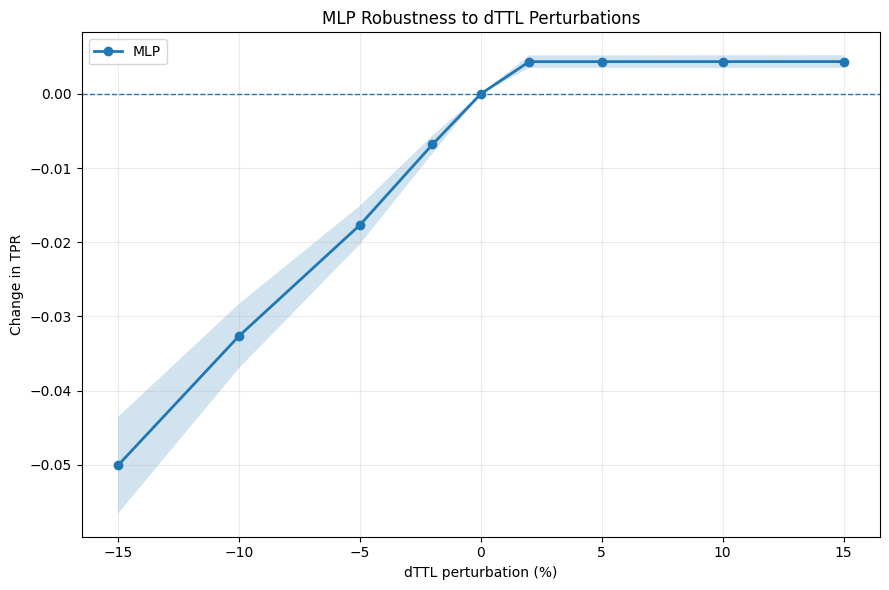

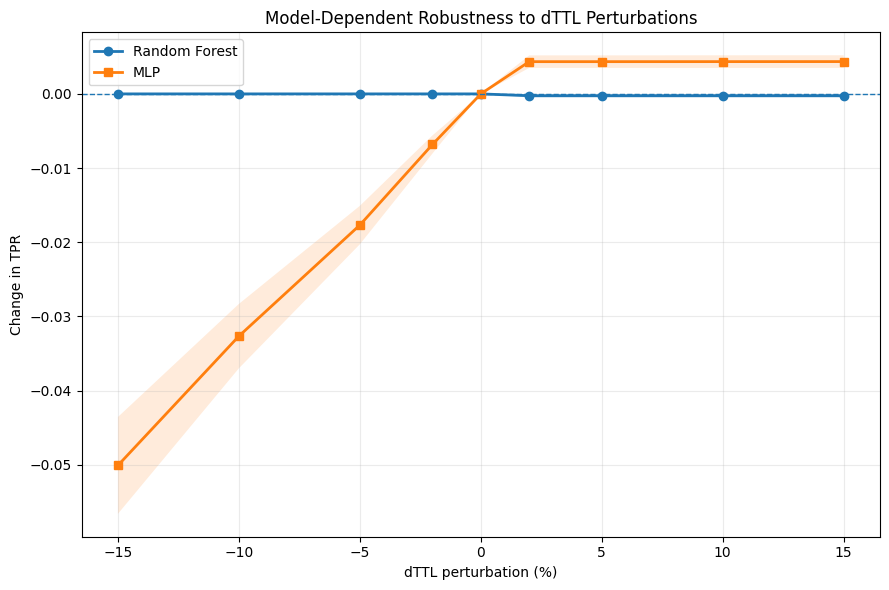

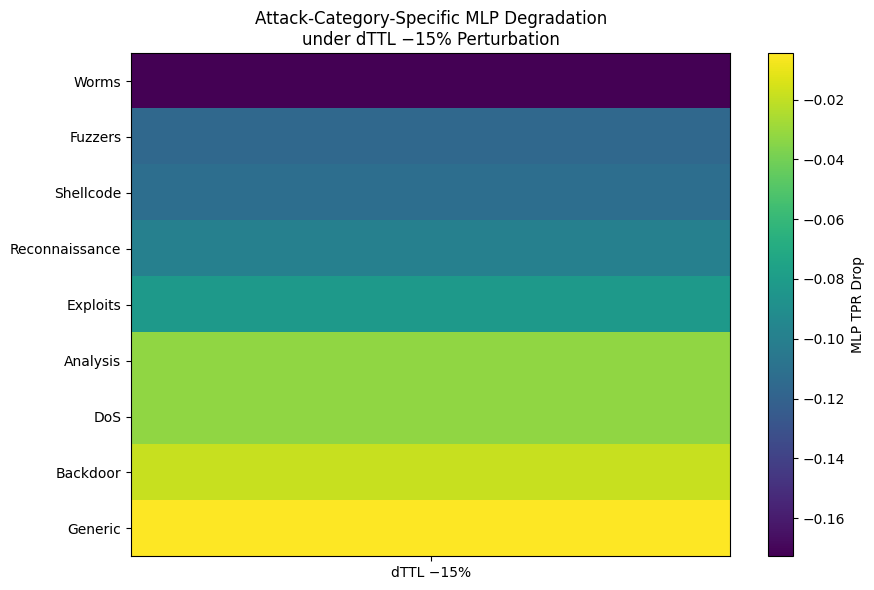

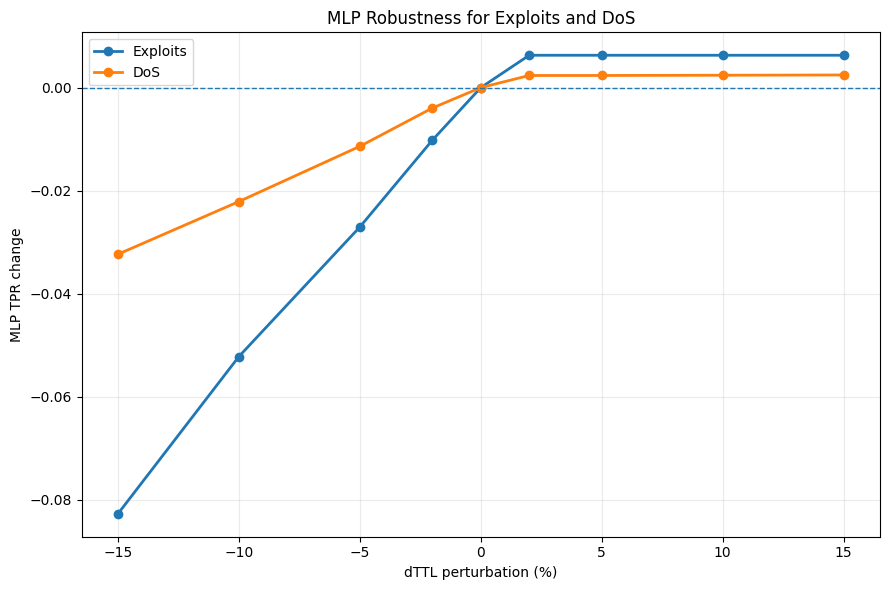



KEY PREPRINT RESULTS
Worms              | MLP ΔTPR = -0.1727 ± 0.0305
Shellcode          | MLP ΔTPR = -0.1116 ± 0.0221
Fuzzers            | MLP ΔTPR = -0.1160 ± 0.0196
Reconnaissance     | MLP ΔTPR = -0.0993 ± 0.0100
Exploits           | MLP ΔTPR = -0.0827 ± 0.0147
DoS                | MLP ΔTPR = -0.0323 ± 0.0077
Generic            | MLP ΔTPR = -0.0045 ± 0.0003


FILES CREATED

fig1_mlp_dttl_robustness.png
fig2_rf_vs_mlp_dttl.png
fig3_dttl_attack_category_heatmap.png
fig4_exploits_dos_dttl.png

table_dttl_overall_robustness.csv
table_dttl_attack_category.csv

VISUALIZATION COMPLETE


In [31]:
# ================================================================
# VISUALIZATION — TTL ROBUSTNESS RESULTS FOR PREPRINT
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("PREPRINT VISUALIZATION — TTL ROBUSTNESS")
print("=" * 80)


# ================================================================
# 1. LOAD RESULTS
# ================================================================

summary_file = "ttl_multiseed_mean_sd.csv"
category_file = "ttl_attack_category_mean_sd_ci.csv"

summary = pd.read_csv(summary_file)
category = pd.read_csv(category_file)

print("\nLoaded:")
print(summary_file)
print(category_file)


# ================================================================
# 2. HELPER
# ================================================================

def sort_perturbations(df):

    return df.sort_values(
        "Perturbation (%)"
    ).reset_index(drop=True)


# ================================================================
# 3. FIGURE 1
# OVERALL MLP ROBUSTNESS — dttl
# ================================================================

dttl = summary[
    summary["TTL Feature"] == "dttl"
].copy()

dttl = sort_perturbations(dttl)

x = dttl["Perturbation (%)"].to_numpy()

mlp_mean = dttl[
    "MLP TPR Drop Mean"
].to_numpy()

mlp_sd = dttl[
    "MLP TPR Drop SD"
].to_numpy()

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    mlp_mean,
    marker="o",
    linewidth=2,
    label="MLP"
)

plt.fill_between(
    x,
    mlp_mean - mlp_sd,
    mlp_mean + mlp_sd,
    alpha=0.20
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "dTTL perturbation (%)"
)

plt.ylabel(
    "Change in TPR"
)

plt.title(
    "MLP Robustness to dTTL Perturbations"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig1_mlp_dttl_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 4. FIGURE 2
# RF VS MLP — dttl
# ================================================================

rf_mean = dttl[
    "RF TPR Drop Mean"
].to_numpy()

rf_sd = dttl[
    "RF TPR Drop SD"
].to_numpy()

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    rf_mean,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

plt.fill_between(
    x,
    rf_mean - rf_sd,
    rf_mean + rf_sd,
    alpha=0.15
)

plt.plot(
    x,
    mlp_mean,
    marker="s",
    linewidth=2,
    label="MLP"
)

plt.fill_between(
    x,
    mlp_mean - mlp_sd,
    mlp_mean + mlp_sd,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "dTTL perturbation (%)"
)

plt.ylabel(
    "Change in TPR"
)

plt.title(
    "Model-Dependent Robustness to dTTL Perturbations"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig2_rf_vs_mlp_dttl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 5. FIGURE 3
# ATTACK-CATEGORY HEATMAP
# dttl at -15%
# ================================================================

cat15 = category[
    (category["TTL Feature"] == "dttl")
    &
    (category["Perturbation (%)"] == -15)
].copy()

heatmap_data = cat15.set_index(
    "Attack Category"
)[
    "MLP TPR Drop"
]

# Sort by degradation
heatmap_data = heatmap_data.sort_values()

plt.figure(
    figsize=(9, 6)
)

values = heatmap_data.to_numpy()

plt.imshow(
    values.reshape(-1, 1),
    aspect="auto"
)

plt.colorbar(
    label="MLP TPR Drop"
)

plt.yticks(
    np.arange(len(heatmap_data)),
    heatmap_data.index
)

plt.xticks(
    [0],
    ["dTTL −15%"]
)

plt.title(
    "Attack-Category-Specific MLP Degradation\n"
    "under dTTL −15% Perturbation"
)

plt.tight_layout()

plt.savefig(
    "fig3_dttl_attack_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 6. FIGURE 4
# EXPLOITS + DOS
# ================================================================

important_categories = [
    "Exploits",
    "DoS"
]

important = category[
    (category["TTL Feature"] == "dttl")
    &
    (
        category["Attack Category"]
        .isin(important_categories)
    )
].copy()

important = important.sort_values(
    [
        "Attack Category",
        "Perturbation (%)"
    ]
)

plt.figure(
    figsize=(9, 6)
)

for attack_type in important_categories:

    subset = important[
        important["Attack Category"]
        == attack_type
    ]

    plt.plot(
        subset["Perturbation (%)"],
        subset["MLP TPR Drop"],
        marker="o",
        linewidth=2,
        label=attack_type
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "dTTL perturbation (%)"
)

plt.ylabel(
    "MLP TPR change"
)

plt.title(
    "MLP Robustness for Exploits and DoS"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig4_exploits_dos_dttl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 7. CREATE PUBLICATION SUMMARY TABLE
# ================================================================

publication_table = dttl[
    [
        "Perturbation (%)",

        "RF TPR Mean",
        "RF TPR SD",
        "RF TPR Drop Mean",
        "RF TPR Drop SD",

        "MLP TPR Mean",
        "MLP TPR SD",
        "MLP TPR Drop Mean",
        "MLP TPR Drop SD"
    ]
].copy()

publication_table = publication_table.round(6)

publication_table.to_csv(
    "table_dttl_overall_robustness.csv",
    index=False
)


# ================================================================
# 8. CATEGORY TABLE FOR PAPER
# ================================================================

category_paper = category[
    category["TTL Feature"] == "dttl"
].copy()

category_paper = category_paper[
    [
        "Perturbation (%)",
        "Attack Category",
        "Samples",

        "RF TPR",
        "RF TPR Drop",

        "MLP TPR",
        "MLP TPR Drop",

        "MLP TPR Drop SD",
        "MLP TPR Drop CI Low",
        "MLP TPR Drop CI High"
    ]
].sort_values(
    [
        "Perturbation (%)",
        "Attack Category"
    ]
)

category_paper.to_csv(
    "table_dttl_attack_category.csv",
    index=False
)


# ================================================================
# 9. PRINT KEY NUMBERS
# ================================================================

print("\n")
print("=" * 90)
print("KEY PREPRINT RESULTS")
print("=" * 90)

for attack_type in [
    "Worms",
    "Shellcode",
    "Fuzzers",
    "Reconnaissance",
    "Exploits",
    "DoS",
    "Generic"
]:

    row = category[
        (category["TTL Feature"] == "dttl")
        &
        (category["Perturbation (%)"] == -15)
        &
        (category["Attack Category"] == attack_type)
    ]

    if len(row) == 0:
        continue

    row = row.iloc[0]

    print(
        f"{attack_type:18s} | "
        f"MLP ΔTPR = "
        f"{row['MLP TPR Drop']:.4f} "
        f"± {row['MLP TPR Drop SD']:.4f}"
    )


print("\n")
print("=" * 90)
print("FILES CREATED")
print("=" * 90)

print("""
fig1_mlp_dttl_robustness.png
fig2_rf_vs_mlp_dttl.png
fig3_dttl_attack_category_heatmap.png
fig4_exploits_dos_dttl.png

table_dttl_overall_robustness.csv
table_dttl_attack_category.csv
""")

print("=" * 90)
print("VISUALIZATION COMPLETE")
print("=" * 90)